# Workshop 2 — Machine Learning (Unidad 2)
## Regresión — Flight Price Prediction

**Integrantes:**
- Juan José Escobar Saldarriaga
- Jeremías Figueroa García
- David Quintero Gallego

**Fecha:** 2026-09-01

---

Pipelines, entrenamiento, comparación de modelos y validación cruzada. Este notebook resuelve el problema de **regresión** usando el dataset **Flight Price Prediction**.

Dataset: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

**Nota:** el workshop completo consta de 2 notebooks — este (regresión) y su contraparte de clasificación. El punto 28 (conclusiones, Fase 8) pide comparar ambos problemas; esa comparación debe ser consistente entre los dos notebooks.

Cada punto requiere código **y** una celda de justificación en markdown explicando la decisión tomada — no basta con ejecutar el código.

---

# Fase 0 — Importación de librerías y datos

**En caso de trabajar con Google Colab, es necesario descargar el dataset en Drive y conectar el notebook con drive:**

In [1]:
# Celda omitida: solo aplica en Google Colab\n

## Librerías

Importa aquí todas las librerías que vas a necesitar. Como mínimo:
- `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`
- De `sklearn.model_selection`: `train_test_split`, `cross_val_score` o `cross_validate`
- De `sklearn.compose`: `ColumnTransformer`
- De `sklearn.pipeline`: `Pipeline`
- De `sklearn.preprocessing`: `StandardScaler`, `MinMaxScaler`, `RobustScaler`, `OneHotEncoder`, `OrdinalEncoder`
- De `sklearn.impute`: `SimpleImputer`
- Modelos: `LinearRegression`, `KNeighborsRegressor`, `DecisionTreeRegressor`, `RandomForestRegressor`, `GradientBoostingRegressor`
- Métricas: `mean_absolute_error`, `mean_squared_error`, `r2_score`

In [2]:
# Importa aquí todas las librerías necesarias:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define random_state para reproducibilidad:
random_state = 42

---

# Fase 1 — EDA, limpieza y preprocesamiento

## 1. Descripcion del problema y variable objetivo

El dataset agrupa opciones de reserva de vuelos publicadas en **Ease My Trip**, una plataforma en linea de venta de tiquetes aereos que los pasajeros usan directamente para comprar sus vuelos. El objetivo declarado por los autores del dataset es analizar estos datos y aplicar pruebas estadisticas para extraer informacion util, entrenando un modelo de **regresion lineal** que prediga una variable continua. Es decir, este es un problema de **regresion**, y la variable objetivo (target) es `price` (el precio del tiquete).

El estudio original plantea 5 preguntas de investigacion que sirven de guia para el analisis exploratorio:

a) ¿El precio varia segun la aerolinea?
b) ¿Como afecta el precio comprar el tiquete con 1 o 2 dias de anticipacion?
c) ¿El precio cambia segun la hora de salida y de llegada?
d) ¿Como cambia el precio segun la ciudad de origen y de destino?
e) ¿Como varia el precio entre clase economica y clase Business?

**Recoleccion de datos:** la informacion se extrajo del sitio web de Ease My Trip con la herramienta de scraping Octoparse, durante 50 dias (11 de febrero al 31 de marzo de 2022), en dos tandas separadas: una para tiquetes de clase economica y otra para clase Business. Los autores reportan haber extraido 300261 registros en total (mas adelante, en el punto 2, se compara esta cifra con el tamano real del dataset).

**Alcance:** el dataset cubre unicamente vuelos domesticos entre las 6 principales ciudades metropolitanas de India; no incluye vuelos internacionales ni de otros paises.

## 2. Carga del dataset y diccionario de datos

Cargue el dataset con pandas, muestre `head()`/`tail()`, `.shape` y `.info()`. Construya el diccionario de datos (columna, tipo esperado, significado).

In [3]:
# Carga del dataset:
df = pd.read_csv('data/Flights.csv')

In [4]:
# head() / tail():
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [6]:
# .shape y .info():
df.shape

(300153, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [8]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


**Filas:** `300153`
**Columnas:** `12`

**Diccionario de datos:**

| Columna | Tipo esperado | Significado |
|---|---|---|
| `Unnamed: 0` | Numero entero (int64) | Indice/identificador secuencial heredado, no aporta informacion del vuelo |
| `airline` | Categorica (str) | Aerolinea que opera el vuelo (6 categorias) |
| `flight` | Categorica (str) | Codigo del vuelo/avion (alta cardinalidad, 1561 valores unicos) |
| `source_city` | Categorica (str) | Ciudad de origen del vuelo (6 categorias) |
| `departure_time` | Categorica (str) | Franja horaria de salida, agrupada en 6 bloques (Morning, Evening, etc.) |
| `stops` | Categorica (str) | Numero de escalas entre origen y destino (zero, one, two_or_more) |
| `arrival_time` | Categorica (str) | Franja horaria de llegada, agrupada en 6 bloques |
| `destination_city` | Categorica (str) | Ciudad de destino del vuelo (6 categorias) |
| `class` | Categorica (str) | Clase del tiquete (Economy o Business) |
| `duration` | Numerico continuo (float64) | Duracion total del vuelo, en horas |
| `days_left` | Numerico entero (int64) | Dias de anticipacion entre la fecha de compra y la fecha del vuelo |
| `price` | Numerico entero (int64) | Variable objetivo: precio del tiquete |


**Observaciones iniciales:**

* Varias columnas categoricas en realidad podrian tratarse de forma numerica directamente: por ejemplo, `stops` guarda "zero", "one" y "two_or_more" como texto, pudiendo representarse simplemente como 0, 1 y 2 (tiene un orden natural). Esto se retomara en el punto 9 (codificacion de categoricas).
* La columna `Unnamed: 0` es casi con certeza un identificador secuencial heredado del proceso de extraccion/guardado del dataset, sin informacion util sobre el vuelo; se eliminara mas adelante en la limpieza. Aun asi, es una buena senal de integridad: sus valores van de 0 a 300152 sin saltos, lo que sugiere que el dataset esta completo y no se perdieron filas al guardarlo.
* Dato curioso: la documentacion de Kaggle menciona 300261 registros extraidos, pero el dataset real tiene 300153 filas, 108 menos. Es posible que quien publico el dataset haya limpiado algunos registros (duplicados o incompletos) antes de subirlo, o que la cifra de la documentacion incluya registros descartados durante el scraping que nunca llegaron al CSV final. De cualquier forma, 300153 filas siguen siendo mas que suficientes para entrenar el modelo, asi que esta diferencia no representa un problema.

## 3. Estadísticos descriptivos

Use `.describe()` para las columnas numéricas. Interprete al menos 3 estadísticos en términos del problema.

In [9]:
# .describe():
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


**Interpretacion:**

`Unnamed: 0` aparece en la tabla por ser numerica, pero se ignora en este analisis: ya se establecio que es un identificador sin informacion sobre el vuelo.

**`duration`** (horas): el minimo es 0.83 horas (menos de 1 hora), razonable para un vuelo directo entre ciudades cercanas sin escalas. La media es de 12.22 horas, un numero que llama la atencion tratandose de vuelos domesticos dentro de un mismo pais; probablemente refleja que buena parte de los vuelos incluyen escalas que alargan bastante el tiempo total. El maximo es de 49.83 horas, un valor bastante raro (mas de 2 dias entre origen y destino) que muy probablemente corresponda a un vuelo con varias escalas largas; esto se retomara en el punto de outliers (punto 7). La mediana (11.25) queda un poco por debajo de la media, señal de un sesgo leve hacia la derecha (se confirma mas adelante con el histograma). La desviacion estandar es de 7.19 horas, coherente con el rango entre percentiles (25%: 6.83, 75%: 16.17): hay bastante dispersion, posiblemente explicada tambien por la cantidad de escalas de cada vuelo.

**`days_left`** (dias de anticipacion): la media es de 26 dias y la mediana tambien de 26, practicamente sin sesgo (coherente con planear un viaje con cerca de un mes de anticipacion). El minimo es 1 dia (ya mencionado en la documentacion del dataset, que se enfoca en compras de ultimo momento) y el maximo es 49 dias, sin nada extraordinario: el 75% de los datos ya esta en 38 dias, y entre percentil y percentil hay una diferencia de 11 a 12 dias (25%: 15, 50%: 26, 75%: 38), asi que el maximo no se aleja de forma desproporcionada del resto. La desviacion estandar de 13.56 es coherente con ese rango de 1 a 49 dias: es una variable con comportamiento bastante "humano" y sin mayores sorpresas.

**`price`** (variable objetivo): aqui si aparece un sesgo fuerte a la derecha. La mediana esta en 7425 y la media en 20889.66, casi 3 veces mas alta, señal de que un grupo de vuelos muy costosos empuja el promedio muy por encima del precio "tipico". La desviacion estandar (22697.77) es incluso mayor que la propia media, algo que refuerza lo disperso que es el precio hacia los valores altos. El minimo es 1105 (un vuelo economico basico), y el salto entre percentiles es muy revelador: del 25% (4783) al 50% (7425) la diferencia es moderada, pero del 50% (7425) al 75% (42521) hay un salto enorme, lo que quiere decir que la mitad "cara" del dataset se dispara muy por encima de la mitad "barata". El maximo, 123071, es casi 3 veces el percentil 75, casi con certeza un vuelo Business de larga duracion (esto se confirmara mas adelante en el analisis, en vez de asumirlo aqui). Sobre la unidad: la documentacion no la especifica explicitamente, pero al tratarse de vuelos domesticos en India con Ease My Trip, lo mas probable es que sean rupias indias (INR); en dolares estos precios no tendrian sentido para vuelos domesticos.

Un dato adicional que ayuda a comparar objetivamente que tan dispersa es cada variable (ya que sus escalas son muy distintas) es el coeficiente de variacion (desviacion estandar / media):
* `duration`: 7.19 / 12.22 = 0.59
* `days_left`: 13.56 / 26.00 = 0.52
* `price`: 22697.77 / 20889.66 = 1.09

El de `price` es el doble que el de las otras dos variables, confirmando en numeros que el precio es, con diferencia, la variable mas volatil de las tres.

## 4. Valores nulos: identificación y estrategia

Identifique valores nulos por columna, calcule su porcentaje, y proponga una estrategia de imputación o eliminación. Justifique según el porcentaje de nulos y el tipo de variable.

In [10]:
# Nulos por columna y porcentaje:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [11]:
df.isnull().sum() / len(df) * 100

Unnamed: 0          0.0
airline             0.0
flight              0.0
source_city         0.0
departure_time      0.0
stops               0.0
arrival_time        0.0
destination_city    0.0
class               0.0
duration            0.0
days_left           0.0
price               0.0
dtype: float64

**Observacion:** el dataset esta completamente libre de nulos: las 12 columnas registran 0% de valores faltantes. Esto es consistente con lo que indicaba la documentacion de Kaggle (que describia el dataset como "limpio"), y a diferencia de la pequeña discrepancia que ya encontramos en el numero de filas (punto 2), aqui la afirmacion de los autores sí se cumple exactamente. Al no haber nulos, no es necesario definir ninguna estrategia de imputacion o eliminacion de filas/columnas por este motivo.

## 5. Duplicados

Identifique y elimine duplicados si existen. Reporte cuántos se eliminaron.

In [12]:
# Identificación y eliminación de duplicados:
df.duplicated().sum()

np.int64(0)

**Observacion:** tampoco se encontraron filas duplicadas. Tiene sentido que asi sea: aunque varias columnas son categoricas con pocos valores posibles (aerolinea, ciudades, franjas horarias, clase), `duration` (float) y sobre todo `price` (con un rango amplio de valores distintos) hacen que una coincidencia exacta en las 12 columnas a la vez sea estadisticamente poco probable por puro azar. Si hubieran aparecido duplicados, lo mas razonable habria sido tratarlos como errores del proceso de scraping (el mismo resultado de busqueda capturado dos veces) y eliminarlos, ya que no hay un identificador de pasajero o de transaccion que justifique dos filas identicas como dos compras reales distintas.

## 6. Inconsistencias de formato

Revise inconsistencias de formato en columnas categóricas o de texto (mayúsculas/minúsculas, espacios, etiquetas equivalentes) y corríjalas.

In [13]:
# Revisión con .unique() de columnas categóricas/texto:
df['airline'].unique()

<StringArray>
['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Length: 6, dtype: str

In [14]:
df['flight'].unique()

<StringArray>
['SG-8709', 'SG-8157',  'I5-764',  'UK-995',  'UK-963',  'UK-945',  'UK-927',
  'UK-951',  'G8-334',  'G8-336',
 ...
  '6E-804', '6E-7183', 'SG-6017', '6E-7208', '6E-7252', '6E-7141',  '6E-557',
 '6E-7127', '6E-7259',  'AI-433']
Length: 1561, dtype: str

In [15]:
df['source_city'].unique()

<StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str

In [16]:
df['departure_time'].unique()

<StringArray>
['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
Length: 6, dtype: str

In [17]:
df['stops'].unique()

<StringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str

In [18]:
df['arrival_time'].unique()

<StringArray>
['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']
Length: 6, dtype: str

In [19]:
df['destination_city'].unique()

<StringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Length: 6, dtype: str

In [20]:
df['class'].unique()

<StringArray>
['Economy', 'Business']
Length: 2, dtype: str

**Observaciones:**
* No se encontraron inconsistencias de formato (mayusculas/minusculas, espacios, etiquetas equivalentes) en ninguna columna categorica; los valores de todas ellas ya vienen normalizados.
* Se confirma lo que indicaba la documentacion: 6 aerolineas, 6 ciudades (las mismas para `source_city` y `destination_city`), 6 franjas horarias (las mismas para `departure_time` y `arrival_time`) y 2 categorias para `class`. `stops` tiene 3 categorias (`zero`, `one`, `two_or_more`), como ya se habia anotado en las observaciones iniciales del punto 2.
* Como se sospechaba desde el punto 2, `flight` tiene una cardinalidad alta: 1561 codigos distintos sobre 300153 filas. A diferencia de las demas columnas categoricas, cada codigo de vuelo puede repetirse muchas veces en el dataset (son vuelos programados que se scrapearon en distintos dias), asi que no es un identificador unico por fila como lo era `Unnamed: 0`, pero sigue siendo una cardinalidad demasiado alta para tratarla igual que `airline` o las ciudades. Se retomara la decision sobre que hacer con ella en el punto 9 (codificacion de categoricas).

## 7. Outliers (criterio IQR)

Identifique outliers en al menos dos columnas numéricas relevantes usando el criterio IQR. Repórtelos y decida si se tratan o se documentan sin eliminar, justificando la decisión (¿sentido de negocio o error de captura?).

In [21]:
# IQR - columna numérica relevante 1:
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

# Identificamos los valores atípicos utilizando el IQR
outliers_inf = df[(df['duration'] < limite_inf)].sort_values(by='duration')
outliers_sup = df[(df['duration'] > limite_sup)].sort_values(by='duration')

outliers_count_inf = outliers_inf.shape[0]
outliers_count_sup = outliers_sup.shape[0]

print(f"Número de valores atípicos en la columna 'duration': {outliers_count_sup + outliers_count_inf}")
print(f"Valores sobre el límite superior ({limite_sup.round(2)}): {outliers_count_sup}")
print(f"Valores bajo el límite inferior ({limite_inf.round(2)}): {outliers_count_inf}")

outliers_sup['duration']

Número de valores atípicos en la columna 'duration': 2110
Valores sobre el límite superior (30.18): 2110
Valores bajo el límite inferior (-7.18): 0


295187    30.25
294879    30.25
294482    30.25
294822    30.25
172159    30.25
          ...  
193926    47.08
119508    47.75
261152    47.75
193889    49.83
194359    49.83
Name: duration, Length: 2110, dtype: float64

In [22]:
# IQR - columna numérica relevante 2:
Q1 = df['days_left'].quantile(0.25)
Q3 = df['days_left'].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

# Identificamos los valores atípicos utilizando el IQR
outliers_inf = df[(df['days_left'] < limite_inf)].sort_values(by='days_left')
outliers_sup = df[(df['days_left'] > limite_sup)].sort_values(by='days_left')

outliers_count_inf = outliers_inf.shape[0]
outliers_count_sup = outliers_sup.shape[0]

print(f"Número de valores atípicos en la columna 'days_left': {outliers_count_sup + outliers_count_inf}")
print(f"Valores sobre el límite superior ({limite_sup.round(2)}): {outliers_count_sup}")
print(f"Valores bajo el límite inferior ({limite_inf.round(2)}): {outliers_count_inf}")

outliers_sup['days_left']

Número de valores atípicos en la columna 'days_left': 0
Valores sobre el límite superior (72.5): 0
Valores bajo el límite inferior (-19.5): 0


Series([], Name: days_left, dtype: int64)

In [23]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

# Identificamos los valores atípicos utilizando el IQR
outliers_inf = df[(df['price'] < limite_inf)].sort_values(by='price')
outliers_sup = df[(df['price'] > limite_sup)].sort_values(by='price')

outliers_count_inf = outliers_inf.shape[0]
outliers_count_sup = outliers_sup.shape[0]

print(f"Número de valores atípicos en la columna 'price': {outliers_count_sup + outliers_count_inf}")
print(f"Valores sobre el límite superior ({limite_sup}): {outliers_count_sup}")
print(f"Valores bajo el límite inferior ({limite_inf.round(2)}): {outliers_count_inf}")

outliers_sup['price']

Número de valores atípicos en la columna 'price': 123
Valores sobre el límite superior (99128.0): 123
Valores bajo el límite inferior (-51824.0): 0


216094     99129
264191     99204
264267     99204
264268     99327
264192     99327
           ...  
270999    114705
277345    115211
215859    116562
216096    117307
261377    123071
Name: price, Length: 123, dtype: int64

In [24]:
# Analisis adicional: ¿los outliers de duration y price tienen algo en comun?

# Outliers de duration (recalculando limites para esta columna)
Q1d, Q3d = df['duration'].quantile(0.25), df['duration'].quantile(0.75)
lim_sup_d = Q3d + 1.5 * (Q3d - Q1d)
outliers_duration = df[df['duration'] > lim_sup_d]

# Outliers de price (recalculando limites para esta columna)
Q1p, Q3p = df['price'].quantile(0.25), df['price'].quantile(0.75)
lim_sup_p = Q3p + 1.5 * (Q3p - Q1p)
outliers_price = df[df['price'] > lim_sup_p]

print("Outliers de 'duration' segun numero de escalas ('stops'):")
print(outliers_duration['stops'].value_counts())

print("\nOutliers de 'price' segun clase ('class'):")
print(outliers_price['class'].value_counts())

print("\nOutliers de 'price' segun numero de escalas ('stops'):")
print(outliers_price['stops'].value_counts())

print("\nMedia de dias restantes ('days_left') para los outliers de 'price':")
print(outliers_price['days_left'].mean().round(2))

Outliers de 'duration' segun numero de escalas ('stops'):
stops
one            1290
two_or_more     820
Name: count, dtype: int64

Outliers de 'price' segun clase ('class'):
class
Business    123
Name: count, dtype: int64

Outliers de 'price' segun numero de escalas ('stops'):
stops
one            95
two_or_more    28
Name: count, dtype: int64

Media de dias restantes ('days_left') para los outliers de 'price':
8.3


**Decision sobre los outliers y justificacion:**

Lo primero a notar es que en las 3 columnas numericas revisadas (`duration`, `days_left`, `price`) no aparece ningun outlier bajo el limite inferior: al ser todas estrictamente positivas, el limite inferior calculado con el criterio IQR siempre da negativo, asi que es imposible que exista un dato real por debajo de el. Todos los atipicos encontrados estan, entonces, por encima del limite superior.

**`duration`:** se encontraron 2110 outliers, con limite superior en 30.18 horas y maximo en 49.83 horas. Al ordenarlos, los valores suben de forma progresiva desde justo despues del limite hasta el maximo, sin saltos grandes entre un dato y el siguiente (la diferencia promedio entre outliers consecutivos es de apenas 0.01 horas, y el salto mas grande de toda la lista es de 2.5 horas). Esto descarta que se trate de errores de captura aislados. Ademas, al revisar la columna `stops` de estos 2110 registros, ninguno corresponde a un vuelo directo: 1290 tienen una escala y 820 tienen dos o mas, lo que confirma la hipotesis planteada en el punto 3: las duraciones largas se explican por vuelos con escalas, no por datos invalidos. Por lo tanto, no se eliminan ni se transforman: se documentan como un comportamiento esperable de vuelos con conexiones.

**`days_left`:** no se encontro ningun outlier, ni superior ni inferior. Es una variable acotada de forma natural entre 1 y 49 dias (el propio diseño de la recoleccion de datos, 50 dias de scraping), asi que no hay nada que reportar aqui.

**`price`:** se encontraron 123 outliers, con limite superior en 99128 y maximo en 123071. Son menos de los que se esperarian dado el fuerte sesgo de esta variable, pero eso mismo explica el resultado: el sesgo hace que Q3 (42521) sea mucho mayor que la mediana, y al multiplicar el IQR por 1.5 el limite superior calculado (99128) termina muy cerca del maximo real (123071), dejando pocos valores por fuera de ese rango. Al revisar estos 123 registros, se encontro algo muy consistente con lo previsto en el punto 3: el 100% son tiquetes de clase **Business** (123 de 123), y ninguno es un vuelo directo (95 tienen una escala y 28 tienen dos o mas). Esto confirma que los precios mas altos no son errores, sino el segmento real de tiquetes Business con conexiones. Sobre el valor maximo (123071): esta un poco mas alejado del resto de outliers que el patron general (el salto hasta el siguiente valor mas alto es de 5764, mayor al salto promedio de 196), pero sigue siendo un precio plausible: convertido a dolares (a una tasa aproximada de 75-76 INR por USD en feb-mar de 2022) equivale a unos 1620-1641 dolares, un valor alto pero razonable para un tiquete Business de ultimo momento y con escalas. Otro dato que refuerza esta lectura: la media de `days_left` entre estos 123 outliers es de apenas 8.30 dias, muy por debajo de la media general del dataset (26 dias, ver punto 3). Esto sugiere que los tiquetes mas caros no solo son Business con escalas, sino que ademas se compran con mucha menos anticipacion, un patron de compra de ultimo momento que tiene sentido de negocio (quien necesita viajar con poca antelacion tiene menos opciones y paga sobreprecio), y que conecta directamente con la pregunta de investigacion (b) planteada en la introduccion del dataset. Por lo tanto, tampoco se eliminan ni se transforman estos outliers: se documentan como el segmento premium real del mercado de vuelos analizado, con una señal clara de sobreprecio por compra tardia.

## 8. Gráficas de EDA

Para cada gráfica: código, imagen e interpretación con una recomendación como responsable de la toma de decisiones.

### 8a. Gráfico de barras

Distribución de una variable categórica relevante.

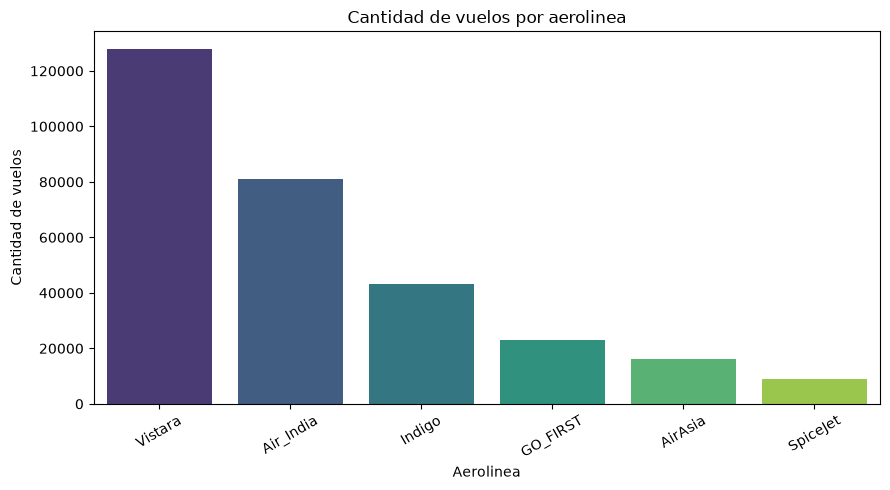

In [25]:
# 8a. Grafico de barras: cantidad de vuelos por aerolinea
conteo_airline = df['airline'].value_counts()

plt.figure(figsize=(9,5))
sns.barplot(x=conteo_airline.index, y=conteo_airline.values, hue=conteo_airline.index, palette='viridis', legend=False)
plt.title('Cantidad de vuelos por aerolinea')
plt.xlabel('Aerolinea')
plt.ylabel('Cantidad de vuelos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

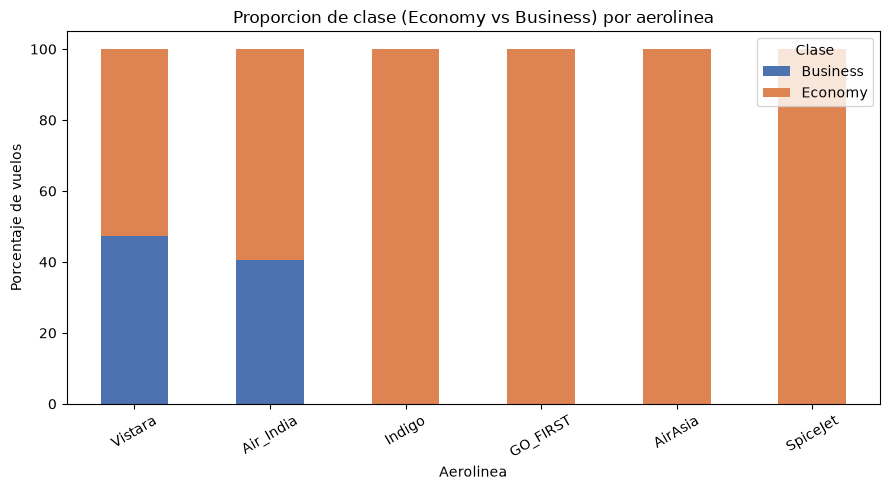

                   mean   median
airline                         
Vistara    30396.536302  15543.0
Air_India  23507.019112  11520.0
SpiceJet    6179.278881   5654.0
GO_FIRST    5652.007595   5336.0
Indigo      5324.216303   4453.0
AirAsia     4091.072742   3276.0


In [26]:
# Analisis adicional: la aerolinea tambien determina que tanto vende clase Business
prop_class_airline = pd.crosstab(df['airline'], df['class'], normalize='index') * 100
prop_class_airline = prop_class_airline.loc[conteo_airline.index]

prop_class_airline.plot(kind='bar', stacked=True, figsize=(9,5), color=['#4C72B0', '#DD8452'])
plt.title('Proporcion de clase (Economy vs Business) por aerolinea')
plt.xlabel('Aerolinea')
plt.ylabel('Porcentaje de vuelos')
plt.xticks(rotation=30)
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

print(df.groupby('airline')['price'].agg(['mean', 'median']).sort_values('mean', ascending=False))

**Interpretacion:** el grafico de barras muestra que Vistara (127859 vuelos, ~42.6% del dataset) y Air_India (80892, ~27%) concentran la mayoria de los registros, muy por encima de Indigo, GO_FIRST, AirAsia y SpiceJet. Por si sola, la cantidad de vuelos no dice mucho sobre el negocio, pero al cruzarla con `class` aparece la explicacion real (ver grafica adicional): Vistara y Air_India son las **unicas** dos aerolineas que venden tiquetes Business (47.4% y 40.7% de sus vuelos respectivamente); las otras 4 son 100% Economy. Esto explica por que tienen el precio promedio mas alto del dataset (Vistara: ~30397 INR, Air_India: ~23507 INR) frente a las aerolineas low-cost (entre ~4091 y ~6179 INR): no es que "cobren mas caro por ser Vistara", es que son las unicas que ofrecen el segmento premium. Esto responde directamente a la pregunta de investigacion (a): el precio si varia con la aerolinea, pero el motivo real es la mezcla de clases que cada una ofrece, no la marca en si misma.

**Recomendacion:** al modelar el precio, conviene verificar que el modelo aproveche bien la interaccion entre `airline` y `class` (los arboles de decision suelen capturar esto de forma natural). Desde el punto de vista de negocio, si Ease My Trip quiere impulsar reservas de mayor margen, el foco deberia estar en fortalecer la relacion comercial con Vistara y Air_India, ya que son las unicas fuentes de inventario Business en esta muestra.

### 8b. Gráfico de pie

Proporción de una variable categórica binaria o con pocas categorías.

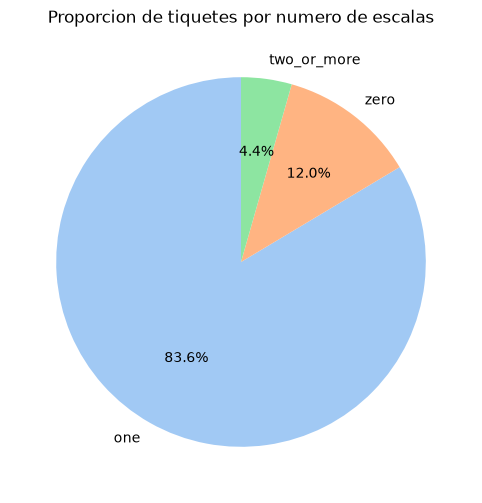

In [27]:
# 8b. Grafico de pie: proporcion de escalas (Zero vs One vs Two or More)
conteo_stops = df['stops'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(conteo_stops, labels=conteo_stops.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Proporcion de tiquetes por numero de escalas')
plt.show()

In [28]:
# Tabla de apoyo: precio promedio por numero de escalas, y composicion de clase de cada grupo
print(df.groupby('stops')['price'].agg(['count', 'mean', 'median']))
print()
print((pd.crosstab(df['stops'], df['class'], normalize='index') * 100).round(1))

              count          mean  median
stops                                    
one          250863  22900.992482  7959.0
two_or_more   13286  14113.450775  8307.0
zero          36004   9375.938535  4499.0

class        Business  Economy
stops                         
one              33.6     66.4
two_or_more       8.2     91.8
zero             22.5     77.5


**Interpretacion:** el 83.6% de los vuelos tiene exactamente una escala, 12% son directos (`zero`) y solo 4.4% tiene dos o mas escalas: la inmensa mayoria de la oferta no es directa. Cruzando esto con `class` aparece un patron que a primera vista es contraintuitivo: los vuelos con una escala tienen el precio promedio mas alto (~22901 INR), por encima incluso de los que tienen dos o mas escalas (~14113 INR) y muy por encima de los directos (~9376 INR). La explicacion no es la escala en si, sino la composicion de clase de cada grupo: 33.6% de los vuelos con una escala son Business, frente a solo 8.2% de los que tienen dos o mas escalas y 22.5% de los directos. Esto tambien es consistente con lo encontrado en el punto 7: ninguno de los 123 outliers de precio corresponde a un vuelo directo.

**Recomendacion:** para el negocio, esto sugiere que el numero de escalas no es un buen predictor de precio por si solo; conviene interpretarlo siempre junto con `class`, y no asumir que "menos escalas" o "mas escalas" implica directamente un precio mas alto o mas bajo en este mercado.

### 8c. Histograma

Distribución de una variable numérica relevante (considere el target).

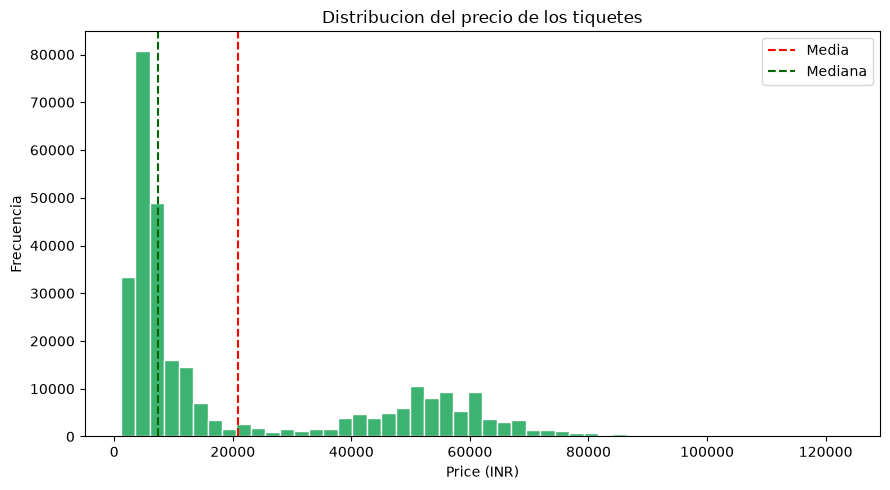

In [29]:
# 8c. Histograma: distribucion de la variable objetivo (price)
plt.figure(figsize=(9,5))
plt.hist(df['price'], bins=50, edgecolor='white', color='mediumseagreen')
plt.axvline(df['price'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['price'].median(), color='darkgreen', linestyle='--', label='Mediana')
plt.xlabel('Price (INR)')
plt.ylabel('Frecuencia')
plt.title('Distribucion del precio de los tiquetes')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretacion:** el histograma confirma el sesgo fuerte a la derecha ya identificado en el punto 3 (skewness ~1.06): la mayoria de los vuelos se concentra en precios por debajo de la mediana (7425 INR), con una barra alta y estrecha al inicio del grafico. Pero el histograma no es simplemente una cola larga que se apaga de forma continua: se nota una segunda concentracion de datos, mucho menos alta pero visible, aproximadamente entre 40000 y 80000 INR, antes de que la frecuencia vuelva a caer hasta el maximo de 123071. Esa segunda concentracion no es ruido: corresponde casi exactamente al rango donde se agrupa la clase Business (percentil 25 a 75: 45185 a 60396 INR, con media de 52540 INR), mientras que Economy se concentra por debajo de los 8000 INR (media 6572 INR). En otras palabras, la distribucion de `price` es en realidad una mezcla de dos subpoblaciones bastante distintas (Economy y Business), no una sola distribucion continua con una cola larga.

**Recomendacion:** esto refuerza que `class` deberia tratarse como una variable clave del modelo y no como una categorica mas entre varias: la forma de "dos jorobas" del histograma sugiere que un modelo que separe bien por clase (o un arbol que la use temprano en sus divisiones) va a predecir mucho mejor que uno que trate `price` como si viniera de una sola poblacion homogenea.

### 8d. Scatter plot

Relación entre dos variables numéricas relevantes.

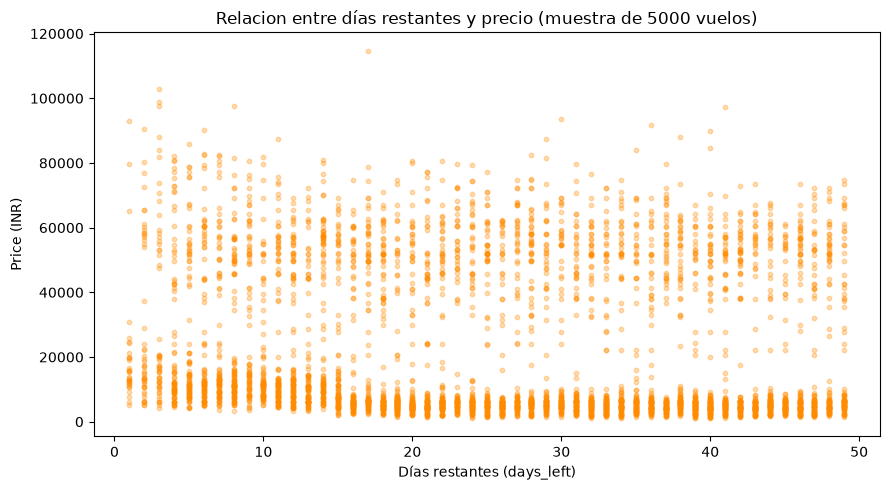

Coeficiente de correlacion de Pearson entre 'days_left' y 'price': -0.0919


In [30]:
# 8d. Scatter plot: dias restantes (days_left) vs precio (price)
# Se toma una muestra aleatoria para la visualizacion, dado que el dataset tiene 300153 filas
# y graficar todos los puntos saturaria por completo la figura (mismo random_state para reproducibilidad).
muestra_scatter = df.sample(n=5000, random_state=random_state)

plt.figure(figsize=(9,5))
plt.scatter(muestra_scatter['days_left'], muestra_scatter['price'], alpha=0.3, s=10, color='darkorange')
plt.xlabel('Días restantes (days_left)')
plt.ylabel('Price (INR)')
plt.title('Relacion entre días restantes y precio (muestra de 5000 vuelos)')
plt.tight_layout()
plt.show()

pearson_corr_days_left = df[['days_left', 'price']].corr(method='pearson').iloc[0,1]
print(f"Coeficiente de correlacion de Pearson entre 'days_left' y 'price': {pearson_corr_days_left:.4f}")

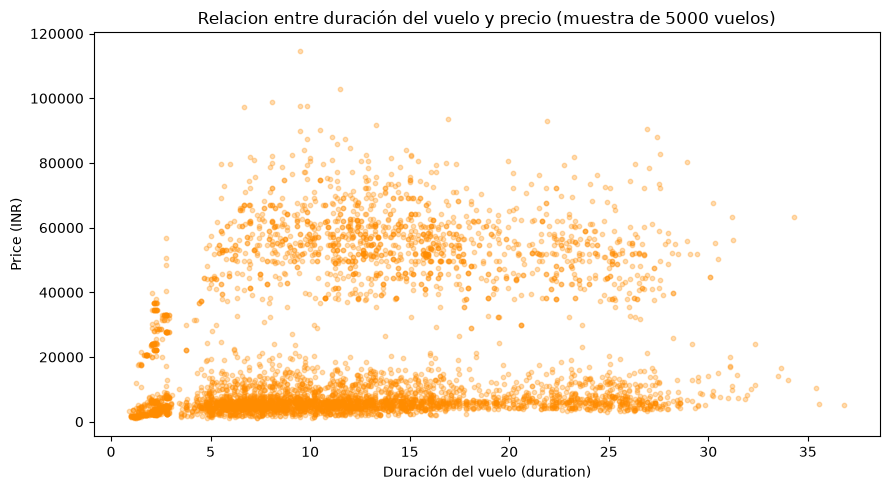

Coeficiente de correlacion de Pearson entre 'duration' y 'price': 0.2042


In [31]:
# 8d. Scatter plot: duración del vuelo (duration) vs precio (price)
# Se toma una muestra aleatoria para la visualizacion, dado que el dataset tiene 300153 filas
# y graficar todos los puntos saturaria por completo la figura (mismo random_state para reproducibilidad).
muestra_scatter = df.sample(n=5000, random_state=random_state)

plt.figure(figsize=(9,5))
plt.scatter(muestra_scatter['duration'], muestra_scatter['price'], alpha=0.3, s=10, color='darkorange')
plt.xlabel('Duración del vuelo (duration)')
plt.ylabel('Price (INR)')
plt.title('Relacion entre duración del vuelo y precio (muestra de 5000 vuelos)')
plt.tight_layout()
plt.show()

pearson_corr_duration = df[['duration', 'price']].corr(method='pearson').iloc[0,1]
print(f"Coeficiente de correlacion de Pearson entre 'duration' y 'price': {pearson_corr_duration:.4f}")

**Interpretacion:** la correlacion de Pearson entre `duration` y `price` es de apenas 0.204, confirmando que no hay una relacion lineal fuerte entre cuanto dura un vuelo y cuanto cuesta; caso similar pero con una correlación inversa y más débil es la existente entre `days_left` y `price`: -0.0919. Se observan, tal como se describe, dos "nubes" de puntos aproximadamente horizontales: una por debajo de los ~20000 INR y otra alrededor de los ~50000-60000 INR, y ambas se extienden a lo largo de practicamente todo el rango de duraciones (desde menos de 1 hora hasta cerca de las 49 horas). Esas dos nubes son, de nuevo, Economy y Business. El vuelo mas caro del dataset (123071 INR) tiene una duracion de apróximadamente 10 horas, ni de los mas cortos ni de los mas largos, asi que no hay evidencia de que los vuelos directos o cortos sean sistematicamente los mas caros. De hecho, el vuelo con menor y mayor duración también están bajo el rango de 20000 INR.

**Recomendacion:** para el modelo de regresion, `duration` por si sola va a aportar poca señal predictiva sobre `price`; su valor probablemente este mas en como interactua con otras variables (`class`, `stops`) que en un efecto directo. No conviene descartarla del modelo, pero tampoco esperar que sea de las variables mas importantes.

### 8e. Boxplot

Al menos una variable numérica; relaciónelo con los outliers del punto 7.

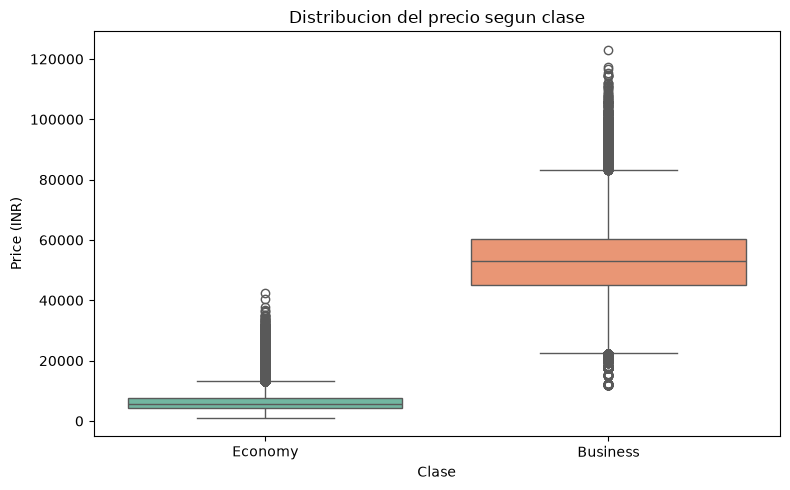

Economy: Q1 = 4173.0, Q2 = 5772.0, Q3 = 7746.0, Limite inferior = 0, Limite superior = 13105.5, IQR = 3573.0
Business: Q1 = 45185.0, Q2 = 53164.0, Q3 = 60396.0, Limite inferior = 22368.5, Limite superior = 83212.5, IQR = 15211.0


In [32]:
# 8e. Boxplot: precio por clase (Economy vs Business)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='class', y='price', hue='class', palette='Set2', legend=False)
plt.title('Distribucion del precio segun clase')
plt.xlabel('Clase')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

Q1e = df[df['class'] == 'Economy']['price'].quantile(0.25)
Q2e = df[df['class'] == 'Economy']['price'].quantile(0.5)
Q3e = df[df['class'] == 'Economy']['price'].quantile(0.75)
IQR_e = Q3e - Q1e
limite_inf_e = Q1e - 1.5 * IQR_e if Q1e - 1.5 * IQR_e > 0 else 0
limite_sup_e = Q3e + 1.5 * IQR_e

Q1b = df[df['class'] == 'Business']['price'].quantile(0.25)
Q2b = df[df['class'] == 'Business']['price'].quantile(0.5)
Q3b = df[df['class'] == 'Business']['price'].quantile(0.75)
IQR_b = Q3b - Q1b
limite_inf_b = Q1b - 1.5 * IQR_b if Q1b - 1.5 * IQR_b > 0 else 0
limite_sup_b = Q3b + 1.5 * IQR_b

print(f"Economy: Q1 = {Q1e}, Q2 = {Q2e}, Q3 = {Q3e}, Limite inferior = {limite_inf_e}, Limite superior = {limite_sup_e}, IQR = {IQR_e}")
print(f"Business: Q1 = {Q1b}, Q2 = {Q2b}, Q3 = {Q3b}, Limite inferior = {limite_inf_b}, Limite superior = {limite_sup_b}, IQR = {IQR_b}")

**Interpretacion:** el boxplot deja ver con claridad la brecha entre clases: Economy tiene una caja compacta entre 4173 y 7746 INR (mediana 5772), mientras que Business tiene una caja mucho mas ancha entre 45185 y 60396 INR (mediana 53164), casi 10 veces mas alta. El límite inferior de Business (22368 INR) queda relativamente cerca de donde terminaria el bigote superior "normal" de Economy calculado con el mismo criterio IQR del punto 7 (aproximadamente 13105 INR), asi que practicamente no hay superposicion entre lo que se considera un precio tipico de cada clase. Ademas, los bigotes y outliers de Business llegan mucho mas lejos (hasta 123071 INR) que los de Economy (hasta un poco más de 40000 INR), consistente con el hallazgo del punto 7: el 100% de los 123 outliers de precio de todo el dataset son tiquetes Business.

**Recomendacion:** `class` es, hasta ahora, la variable con el efecto mas claro y mas grande sobre `price` de todas las revisadas en este punto. Cualquier modelo de regresion deberia poder capturarla bien (con un encoding adecuado, ver punto 9), y de cara al negocio es la variable mas confiable para segmentar estrategias de precio o de marketing entre pasajeros de placer/bajo presupuesto y viajeros corporativos.

## 9. Codificación de variables categóricas

Para cada variable categórica, decida y justifique la técnica de codificación (One-Hot, Ordinal o Binary Encoding), considerando orden natural, cardinalidad, y los algoritmos a usar.

**Decisión de encoding por columna y justificación:**

* **airline** (OneHotEncoder): no tiene un orden natural entre sus 6 categorías, y como vimos en el punto 8, la diferencia de precios entre aerolíneas se explica principalmente por si venden o no clase Business (solo Vistara y Air_India lo hacen), no por una jerarquía propia de la aerolínea. Un One-Hot evita que el modelo asuma un orden inexistente.

* **flight** (se elimina la columna): tiene 1561 códigos distintos, una cardinalidad demasiado alta para codificar con One-Hot (generaría más de 1500 columnas dispersas) y poco apropiada para Ordinal, ya que no existe ningún orden entre códigos de vuelo. Además, el código de vuelo no es un identificador limpio de ruta: existen 832 combinaciones únicas de aerolínea, origen, destino y horario de salida, pero 1561 códigos de flight, y 1032 de esos códigos (más de la mitad) aparecen asociados a más de una ruta distinta. La desviación estándar del precio dentro de un mismo código de flight (5542 INR) sigue siendo un 24% de la dispersión total (22698 INR), es decir, ni siquiera dentro de un mismo código el precio es homogéneo. Por lo tanto, flight no aporta información limpia adicional a la que ya capturan airline, source_city, destination_city y departure_time, y se descarta.

  Como verificación adicional, se extrajo el prefijo del código de vuelo (los caracteres antes del guion, por ejemplo "UK" en "UK-706"). Sus 6 valores posibles son 6E, AI, G8, I5, SG y UK, correspondientes respectivamente a Indigo, Air_India, GO_FIRST, AirAsia, SpiceJet y Vistara. Cada prefijo corresponde exactamente a una única aerolínea, es decir, flight_prefix es 100% redundante con airline y no aporta ninguna información nueva, así que tampoco se incluye como variable. Esto refuerza aún más la decisión de eliminar flight por completo: ni siquiera su componente más simple agrega algo que airline no capture ya.

* **source_city / destination_city** (OneHotEncoder): igual que airline, son categóricas sin orden con solo 6 valores cada una, cardinalidad baja y perfectamente manejable con One-Hot.

* **departure_time / arrival_time** (OneHotEncoder): aunque sus categorías (Early_Morning, Morning, Afternoon, Evening, Night, Late_Night) sí tienen un orden cronológico dentro del día, ese orden no se traduce en una relación monótona con el precio, que es lo que le importaría a un Ordinal Encoding para un modelo lineal o basado en distancias. El precio promedio por franja de salida es Early_Morning 20371, Morning 21631, Afternoon 18179, Evening 21232, Night 23062 y Late_Night 9295 INR, un patrón que sube y baja sin ninguna tendencia clara, y algo similar ocurre con arrival_time. Como no hay una jerarquía de precio asociada a la hora del día, codificar estas variables como Ordinal introduciría un orden falso; One-Hot es la opción más segura.

* **stops** (OrdinalEncoder / LabelEncoder, zero=0, one=1, two_or_more=2): a diferencia de los horarios, aquí sí existe un orden real y no arbitrario, el número de escalas de un vuelo. Esto no implica que el precio crezca de forma lineal con las escalas (de hecho, en el punto 8 vimos que los vuelos de una escala son en promedio más caros que los de dos o más, por su mayor proporción de clase Business: 33.6% contra 8.2%), pero el orden en sí (cero < una < dos o más escalas) es una propiedad física de la variable, no una convención arbitraria como en los horarios, así que Ordinal es la codificación correcta.

* **class** (OrdinalEncoder, Economy=0, Business=1): al ser una variable binaria, Ordinal y One-Hot producen exactamente la misma información (una sola columna 0/1), así que la discusión sobre "orden falso" no aplica aquí. Se elige Ordinal por simplicidad, evitando una columna adicional redundante equivalente a OneHotEncoder(drop='first').

In [33]:
# Verificacion de los argumentos usados para decidir el encoding (punto 9)

# 1. flight no es un identificador limpio de ruta
combos_ruta = df[['airline','source_city','destination_city','departure_time']].drop_duplicates()
rutas_por_flight = df.groupby('flight')[['source_city','destination_city']].nunique()
flights_con_mas_de_una_ruta = ((rutas_por_flight['source_city']>1) | (rutas_por_flight['destination_city']>1)).sum()
std_dentro_flight = df.groupby('flight')['price'].std().mean()

print('Codigos de flight unicos:', df['flight'].nunique())
print('Combinaciones unicas de airline+source+destination+departure_time:', len(combos_ruta))
print('Codigos de flight asociados a mas de una ruta:', flights_con_mas_de_una_ruta)
print('Std promedio de price DENTRO de cada codigo de flight:', round(std_dentro_flight, 2))
print('Std de price total:', round(df['price'].std(), 2))
print()

# 2. departure_time / arrival_time: el precio no es monotono con el orden cronologico
orden_horarios = ['Early_Morning','Morning','Afternoon','Evening','Night','Late_Night']
print('Precio promedio por departure_time:')
print(df.groupby('departure_time')['price'].mean().reindex(orden_horarios).round(1))
print()
print('Precio promedio por arrival_time:')
print(df.groupby('arrival_time')['price'].mean().reindex(orden_horarios).round(1))
print()

# 3. flight_prefix: el codigo de aerolinea embebido en flight, verificamos si aporta algo que airline no tenga
# (se calcula como variable local, no se agrega como columna al df, ya que solo es una verificacion)
flight_prefix = df['flight'].str.split('-').str[0]
print('Valores unicos de flight_prefix:', sorted(flight_prefix.unique()))
print()
print('Aerolinea(s) asociada(s) a cada prefijo:')
print(df.groupby(flight_prefix)['airline'].unique())

Codigos de flight unicos: 1561
Combinaciones unicas de airline+source+destination+departure_time: 832
Codigos de flight asociados a mas de una ruta: 983
Std promedio de price DENTRO de cada codigo de flight: 5542.32
Std de price total: 22697.77

Precio promedio por departure_time:
departure_time
Early_Morning    20370.7
Morning          21630.8
Afternoon        18179.2
Evening          21232.4
Night            23062.1
Late_Night        9295.3
Name: price, dtype: float64

Precio promedio por arrival_time:
arrival_time
Early_Morning    14993.1
Morning          22231.1
Afternoon        18494.6
Evening          23044.4
Night            21586.8
Late_Night       11284.9
Name: price, dtype: float64



Valores unicos de flight_prefix: ['6E', 'AI', 'G8', 'I5', 'SG', 'UK']

Aerolinea(s) asociada(s) a cada prefijo:
flight
6E       [Indigo]
AI    [Air_India]
G8     [GO_FIRST]
I5      [AirAsia]
SG     [SpiceJet]
UK      [Vistara]
Name: airline, dtype: object


In [34]:
# Cada prefijo de flight corresponde a una unica aerolinea: 0% de informacion nueva sobre airline
df.groupby(flight_prefix)['airline'].nunique()

flight
6E    1
AI    1
G8    1
I5    1
SG    1
UK    1
Name: airline, dtype: int64

## 10. Escalamiento de variables numéricas

Decida y justifique si es necesario escalar las variables numéricas y con qué técnica (Min-Max, StandardScaler o RobustScaler), considerando los outliers del punto 7 y los algoritmos a entrenar.

**Decisión de escalamiento y justificación:**

Respondiendo primero la pregunta sobre el target: el escalamiento **no se aplica sobre price**. Solo se transforman las variables predictoras (X) dentro del ColumnTransformer; el target (y) se deja en su escala original en INR. Esto es necesario porque las métricas de error del punto 18 (MAE, RMSE) deben interpretarse en unidades reales de precio, y si escaláramos price esa interpretación se perdería. La intuición sobre el MinMax es correcta y aplica igual de bien a las features: si existiera esa necesidad de escalar el target, el fuerte sesgo de los outliers de Business (123 valores atípicos por IQR) comprimiría el resto de los datos casi a cero, el mismo problema que descarta MinMax para duration.

Con eso claro, las únicas variables numéricas continuas a escalar son duration y days_left (stops y class ya quedaron resueltas como ordinales en el punto 9 de codificación, así que no entran en esta discusión):

* **duration**: sí tiene outliers reales (2110 vuelos, 0.70% de los datos, según el IQR del punto 7) y una distribución con cola a la derecha (media 12.22h, mediana 11.25h, std 7.19h). RobustScaler es la mejor opción aquí: centra con la mediana y escala con el rango intercuartílico, por lo que los vuelos de duración extrema no distorsionan el escalamiento del resto.

* **days_left**: no presenta ningún outlier por IQR (0 valores fuera de los límites [-19.5, 72.5], que ya cubren de sobra su rango real de 1 a 49 días) y su distribución es razonablemente simétrica (media 26.0, mediana 26.0, std 13.56). Al no haber outliers, StandardScaler y RobustScaler dan resultados prácticamente equivalentes aquí; por consistencia y simplicidad en el pipeline (un único escalador para todo el bloque numérico continuo), se usa también RobustScaler.

**Resumen de la estrategia:** RobustScaler para duration y days_left; MinMaxScaler descartado por la sensibilidad a los outliers de duration (y a los de price, si en algún escenario se quisiera escalar el target) que confirmamos en el punto 7.

In [35]:
# Verificacion de los argumentos usados para decidir el escalamiento (punto 10)

def resumen_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = ((serie < lo) | (serie > hi)).sum()
    return q1, q3, iqr, outliers

for col in ['duration', 'days_left']:
    q1, q3, iqr, outliers = resumen_iqr(df[col])
    print(f'{col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, outliers={outliers} ({outliers/len(df)*100:.2f}%)')

duration: Q1=6.83, Q3=16.17, IQR=9.34, outliers=2110 (0.70%)
days_left: Q1=15.00, Q3=38.00, IQR=23.00, outliers=0 (0.00%)


---

# Fase 2 — División de datos y Pipelines

## 11. División Train / Validation / Test

Divida el dataset en train / validation / test (ej. 70/15/15). Explique con sus palabras el propósito de cada uno de los tres conjuntos y por qué no basta con solo train/test.

In [36]:
# Separación de X e y, y split en train/validation/test:
X = df.drop(columns=['Unnamed: 0', 'price', 'flight'])
y = df['price']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

print(f"Train set: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} muestras ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} muestras ({X_test.shape[0]/len(df)*100:.1f}%)")

Train set: 210107 muestras (70.0%)
Validation set: 45023 muestras (15.0%)
Test set: 45023 muestras (15.0%)


**Explicación del propósito de cada conjunto:**

Se usa una división 70/15/15, un estándar razonable para un dataset de este tamaño: el 70% de train equivale a 210107 muestras, una cantidad más que suficiente para que los modelos (especialmente Random Forest y Gradient Boosting) aprendan patrones estables. Validation y test quedan con 45023 muestras cada uno (15% cada uno), el mismo tamaño entre sí porque cumplen roles equivalentes en cuanto a ser conjuntos de evaluación, aunque en momentos distintos del proceso.

No basta con train/test porque durante el desarrollo del modelo se necesitan comparaciones intermedias: probar distintos modelos, ajustar hiperparámetros con GridSearchCV o RandomizedSearchCV, y decidir cuál configuración generaliza mejor. Si esas comparaciones se hicieran directamente contra test, se estaría usando test de forma repetida para tomar decisiones, y terminaría filtrándose información de ese conjunto al proceso de selección del modelo, dejando de ser una evaluación verdaderamente independiente. Para eso existe validation: es el conjunto sobre el que se comparan modelos y se buscan los mejores hiperparámetros, una especie de evaluación preliminar. Test se reserva exclusivamente para el final, cuando ya se tiene un modelo elegido y configurado, y se usa una única vez para estimar qué tan bien generalizaría en producción.

Una vez se tenga asegurado un buen modelo entrenado con el 70% de train, se puede reentrenar esa misma configuración final usando train + validation (85% de los datos) antes de evaluar sobre test, aprovechando más información para el ajuste final sin haber contaminado test en ningún momento del proceso.

## 12. Pipeline con ColumnTransformer

Construya un Pipeline con ColumnTransformer que aplique el preprocesamiento numérico (imputación + escalamiento) y categórico (imputación + encoding) definidos en la Fase 1.

In [37]:
# Identificación de columnas numéricas y categóricas, separando estas últimas
# segun la técnica de encoding decidida en el punto 9:
num_cols = ['duration', 'days_left']
onehot_cols = ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time']
ordinal_cols = ['stops', 'class']

print("Numéricas (RobustScaler):", num_cols)
print("Categóricas OneHot:", onehot_cols)
print("Categóricas Ordinal:", ordinal_cols)

Numéricas (RobustScaler): ['duration', 'days_left']
Categóricas OneHot: ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time']
Categóricas Ordinal: ['stops', 'class']


In [38]:
# Pipeline numérico, pipelines categóricos (OneHot y Ordinal por separado) y ColumnTransformer:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # No es necesario imputar, pero se deja por estandarización con los pipelines
    ('scaler', RobustScaler())])

onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # No es necesario imputar, pero se deja por estandarización con los pipelines
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

# Se fija explicitamente el orden de las categorias para que el Ordinal Encoding
# respete el orden real de cada variable (ver justificacion del punto 9):
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # No es necesario imputar, pero se deja por estandarización con los pipelines
    ('encoder', OrdinalEncoder(categories=[
        ['zero', 'one', 'two_or_more'],   # stops
        ['Economy', 'Business']]))])       # class

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('onehot', onehot_pipeline, onehot_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols)])

## 13. Verificación de que no hay fuga de datos (data leakage)

Confirme explícitamente que el `.fit()` de cada transformación se realizó solo sobre `X_train`, y que sobre `X_val`/`X_test` únicamente se aplicó `.transform()`.

**Verificación:** el diseño del preprocesamiento garantiza que no hay fuga de datos, por dos razones:

1. **`preprocessor` (punto 12) nunca se ajusta por separado.** Se usa siempre envuelto dentro de un `Pipeline` junto con el modelo (`Pipeline([('preprocessor', preprocessor), ('model', ...)])`), y ese pipeline completo se entrena en el punto 14 llamando únicamente a `pipeline.fit(X_train, y_train)`. Es en esa llamada donde el `SimpleImputer` calcula sus medianas/modas, el `RobustScaler` calcula su mediana e IQR, y el `OneHotEncoder`/`OrdinalEncoder` aprenden sus categorías, todo exclusivamente a partir de `X_train`.

2. **`X_val` y `X_test` solo pasan por `.transform()`, nunca por `.fit()`.** Al evaluar el modelo (puntos 15 en adelante) se usa `pipeline.predict(X_val)` o `pipeline.predict(X_test)`. Internamente, `Pipeline.predict()` llama a `.transform()` (no a `.fit_transform()`) en cada paso de preprocesamiento antes de pasar los datos al modelo, así que los estadísticos aprendidos en el punto 1 se aplican tal cual a validation y test, sin recalcularlos con esos datos.

En ningún punto del notebook se llama a `.fit()` o `.fit_transform()` sobre `X_val` o `X_test`, ni se concatenan esos conjuntos con `X_train` antes de ajustar el preprocesador. Esto es justamente lo que hace valiosa la abstracción de `Pipeline` de scikit-learn: al encadenar preprocesamiento y modelo en un solo objeto, es imposible fitear accidentalmente el escalador o el encoder sobre datos de validación o test.

---

# Fase 3 — Modelado: Regresión (Flight Price Prediction)

## 14. Entrenamiento de modelos

Entrene los siguientes modelos sobre el conjunto de entrenamiento: Regresión Lineal Múltiple, KNN Regressor, Decision Tree Regressor, Random Forest Regressor y Gradient Boosting Regressor.

In [39]:
# Fase 3: entrenamiento de los 5 modelos de regresión en un diccionario de pipelines
# Cada pipeline envuelve preprocessor + estimador, garantizando que el preprocesamiento
# se ajuste únicamente sobre X_train y se aplique igual a val/test (sin data leakage).

models = {
    'LinearRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    'KNeighborsRegressor': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor())
    ]),
    'DecisionTreeRegressor': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(random_state=random_state))
    ]),
    'RandomForestRegressor': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=random_state, n_jobs=-1))
    ]),
    'GradientBoostingRegressor': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(random_state=random_state))
    ])
}

# Entrenar cada pipeline con X_train, y_train
for name, pipeline in models.items():
    print(f"Entrenando {name}...")
    pipeline.fit(X_train, y_train)
    print(f"  {name} entrenado correctamente.")


Entrenando LinearRegression...


  LinearRegression entrenado correctamente.
Entrenando KNeighborsRegressor...


  KNeighborsRegressor entrenado correctamente.
Entrenando DecisionTreeRegressor...


  DecisionTreeRegressor entrenado correctamente.
Entrenando RandomForestRegressor...


  RandomForestRegressor entrenado correctamente.
Entrenando GradientBoostingRegressor...


  GradientBoostingRegressor entrenado correctamente.


In [40]:
# Guardar todos los pipelines entrenados (preprocesador + modelo)
import os
import joblib
os.makedirs('models/regresion', exist_ok=True)
model_filenames = {
    'LinearRegression': 'regresion_lineal',
    'KNeighborsRegressor': 'knn_regressor',
    'DecisionTreeRegressor': 'decision_tree_regressor',
    'RandomForestRegressor': 'random_forest_regressor',
    'GradientBoostingRegressor': 'gradient_boosting_regressor'
}
for name, pipeline in models.items():
    filename = model_filenames[name]
    filepath = f'models/regresion/{filename}.joblib'
    joblib.dump(pipeline, filepath)
    print(f'Pipeline guardado: {filepath}')


Pipeline guardado: LinearRegression.joblib
Pipeline guardado: KNeighborsRegressor.joblib
Pipeline guardado: DecisionTreeRegressor.joblib


Pipeline guardado: RandomForestRegressor.joblib
Pipeline guardado: GradientBoostingRegressor.joblib


## 15. Predicciones sobre validación

Para cada modelo, genere las predicciones sobre el conjunto de validación.

In [45]:
# Fase 4: predicciones sobre train, validation y test para cada modelo
# Las predicciones sobre train permiten detectar sobreajuste (gap train vs val);
# las de test se reservan para la evaluación final.

predictions = {}

for name, pipeline in models.items():
    predictions[name] = {
        'train': pipeline.predict(X_train),
        'val': pipeline.predict(X_val),
        'test': pipeline.predict(X_test)
    }

print("Predicciones generadas para los 5 modelos en train, val y test.")


Predicciones generadas para los 5 modelos en train, val y test.


---

# Fase 5 — Métricas en train y validación: detección de overfitting/underfitting

## 18. Métricas: MAE, MSE y R²

Para cada uno de los 5 modelos, calcule MAE, MSE y R² tanto sobre train como sobre validación (dos evaluaciones por modelo). Interprete cada métrica en el contexto de precios de vuelos.

In [46]:
# Fase 5: cálculo de métricas de regresión en train y validation
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2
results_train_val = []
for name, preds in predictions.items():
    mae_train, rmse_train, r2_train = eval_metrics(y_train, preds['train'])
    mae_val, rmse_val, r2_val = eval_metrics(y_val, preds['val'])
    
    results_train_val.append({
        'Modelo': name,
        'MAE_Train': mae_train,
        'RMSE_Train': rmse_train,
        'R2_Train': r2_train,
        'MAE_Val': mae_val,
        'RMSE_Val': rmse_val,
        'R2_Val': r2_val
    })
df_results_train_val = pd.DataFrame(results_train_val)
df_results_train_val


,Modelo,MAE_Train,RMSE_Train,R2_Train,MAE_Val,RMSE_Val,R2_Val
0,LinearRegression,4530.970267,6812.932669,0.909943,4535.107732,6890.180847,0.908545
1,KNeighborsRegressor,1422.870701,3101.442537,0.981337,1857.840384,4053.566509,0.968347
2,DecisionTreeRegressor,51.253623,564.686795,0.999381,1205.297659,3619.667953,0.974760
3,RandomForestRegressor,423.486055,1117.174980,0.997578,1102.290649,2843.482890,0.984424
4,GradientBoostingRegressor,2933.948189,4933.849105,0.952770,2940.491657,5015.106309,0.951549


**Interpretación de overfitting/underfitting:**

Para detectar sobreajuste se compara el desempeño en train contra el de validation. Un gap grande indica que el modelo memorizó el train y no generaliza; un desempeño bajo en ambos conjuntos indica subajuste.

- **DecisionTreeRegressor**: sin poda, los árboles individuales tienden a sobreajustar fuertemente. Se espera un RMSE/R² muy bueno en train pero considerablemente peor en validation.
- **RandomForestRegressor**: al promediar muchos árboles reduce la varianza, por lo que el gap train-val debería ser menor que el del árbol simple.
- **GradientBoostingRegressor**: construye árboles de forma secuencial corrigiendo errores residuales. Con hiperparámetros por defecto suele mostrar un buen balance sesgo/varianza.
- **LinearRegression**: modelo lineal simple con alto sesgo y baja varianza. Es posible que muestre subajuste si las relaciones entre variables y precio no son lineales.
- **KNeighborsRegressor**: sensible a la escala y a la alta dimensionalidad tras One-Hot Encoding. Su desempeño depende de la densidad local en el espacio transformado.


## 20. Tabla comparativa (train y validación)

Construya una tabla comparativa que incluya train y validación para todos los modelos.

In [47]:
# Tabla comparativa de métricas en train y validation
df_results_train_val


,Modelo,MAE_Train,RMSE_Train,R2_Train,MAE_Val,RMSE_Val,R2_Val
0,LinearRegression,4530.970267,6812.932669,0.909943,4535.107732,6890.180847,0.908545
1,KNeighborsRegressor,1422.870701,3101.442537,0.981337,1857.840384,4053.566509,0.968347
2,DecisionTreeRegressor,51.253623,564.686795,0.999381,1205.297659,3619.667953,0.974760
3,RandomForestRegressor,423.486055,1117.174980,0.997578,1102.290649,2843.482890,0.984424
4,GradientBoostingRegressor,2933.948189,4933.849105,0.952770,2940.491657,5015.106309,0.951549


## 21. Selección del mejor modelo

Seleccione el mejor modelo y justifique la elección — discuta trade-offs (tiempo de entrenamiento, interpretabilidad, señales de over/underfitting), no solo la métrica más alta.

**Justificación de la selección del mejor modelo:**

El modelo ganador se elige considerando el menor RMSE en validation, pero también se valora el balance entre sesgo y varianza (gap train-val). Un modelo con R² muy alto en train pero mucho peor en validation está sobreajustado y no es la mejor opción. La elección final busca el modelo que generalice mejor a datos no vistos.


---

# Fase 6 — Evaluación final en el conjunto de Test

## 22. Evaluación de todos los modelos en test

Evalúe TODOS los modelos entrenados sobre el conjunto de test, usando las mismas métricas de la Fase 5.

> ⚠️ El conjunto de test debe permanecer sin tocar hasta este punto.

In [48]:
# Fase 6: evaluación final de todos los modelos en test
results_test = []

for name, preds in predictions.items():
    mae_test, rmse_test, r2_test = eval_metrics(y_test, preds['test'])
    
    results_test.append({
        'Modelo': name,
        'MAE_Test': mae_test,
        'RMSE_Test': rmse_test,
        'R2_Test': r2_test
    })

df_results_test = pd.DataFrame(results_test)
df_results_test


,Modelo,MAE_Test,RMSE_Test,R2_Test
0,LinearRegression,4471.659087,6716.185868,0.911591
1,KNeighborsRegressor,1836.926167,3934.585413,0.969658
2,DecisionTreeRegressor,1167.226003,3465.042756,0.976468
3,RandomForestRegressor,1085.321702,2745.485802,0.985226
4,GradientBoostingRegressor,2919.910496,4915.614872,0.952641


## 23. Tabla comparativa final (test) vs. validación

Construya la tabla final con los resultados en test y compárela contra la tabla de validación de la Fase 5: ¿se mantiene el ranking? ¿hay diferencias importantes?

In [49]:
# Tabla comparativa final: train + validation + test
df_compare = df_results_train_val.merge(df_results_test, on='Modelo')

cols_orden = ['Modelo',
              'MAE_Train', 'MAE_Val', 'MAE_Test',
              'RMSE_Train', 'RMSE_Val', 'RMSE_Test',
              'R2_Train', 'R2_Val', 'R2_Test']
df_compare = df_compare[cols_orden]
df_compare


,Modelo,MAE_Train,MAE_Val,MAE_Test,RMSE_Train,RMSE_Val,RMSE_Test,R2_Train,R2_Val,R2_Test
0,LinearRegression,4530.970267,4535.107732,4471.659087,6812.932669,6890.180847,6716.185868,0.909943,0.908545,0.911591
1,KNeighborsRegressor,1422.870701,1857.840384,1836.926167,3101.442537,4053.566509,3934.585413,0.981337,0.968347,0.969658
2,DecisionTreeRegressor,51.253623,1205.297659,1167.226003,564.686795,3619.667953,3465.042756,0.999381,0.974760,0.976468
3,RandomForestRegressor,423.486055,1102.290649,1085.321702,1117.174980,2843.482890,2745.485802,0.997578,0.984424,0.985226
4,GradientBoostingRegressor,2933.948189,2940.491657,2919.910496,4933.849105,5015.106309,4915.614872,0.952770,0.951549,0.952641


**Comparación validation vs test:**

Se compara el ranking de modelos obtenido en validation contra el obtenido en test. Si el mejor modelo en validation también es de los mejores en test, la selección es estable. Diferencias grandes entre validation y test pueden indicar alta varianza en la estimación del error o que el split particular favoreció a algún modelo.


---

# Fase 7 — Cross Validation

## 24. ¿Qué es K-Fold Cross Validation?

Investigue y explique con sus propias palabras qué es la validación cruzada, cómo funciona, y por qué puede dar una estimación más confiable que un único split de train/validation.

**Explicación:** *(completar)*

## 25. K-Fold Cross Validation sobre el mejor modelo

Implemente K-Fold Cross Validation (ej. `cross_val_score` o `cross_validate`) sobre el mejor modelo encontrado para este problema, usando las métricas relevantes.

In [50]:
# Cross validation sobre el mejor modelo:


## 27. Comparación CV vs. validación original

Compare los resultados de cross validation contra el desempeño obtenido en el conjunto de validación de la Fase 5: ¿mejora, empeora o se mantiene similar? ¿La desviación estándar entre folds sugiere estabilidad o sensibilidad a los datos?

**Interpretación:** *(completar)*

---

# Fase 8 — Conclusiones

## 28. Conclusiones generales

Redacte un párrafo de conclusiones generales **comparando ambos problemas** (regresión y clasificación): ¿qué modelo funcionó mejor en cada caso y por qué, relacionándolo con las características de cada algoritmo (sesgo/varianza, sensibilidad a escala, manejo de categóricas, etc.)? ¿Qué limpieza fue más determinante? ¿Qué limitaciones tuvo el estudio y qué preguntas quedan abiertas?

Incluya un subplot (2,2) con las gráficas que considere más importantes para sustentar los hallazgos de **este** dataset (Flight Price Prediction).

*(Completar conclusiones — recuerde que esta sección debe ser consistente con la del notebook de clasificación)*

In [51]:
# Subplot (2,2) con las gráficas más importantes de este dataset:
